In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/stud.csv")

# Getting some general info from data before visualizing:

# Printing the categorical and numerical data we have:
def data_type_info():
    categorical_columns = df.select_dtypes(
    include=["object", "category", "string", "bool"]
    ).columns.tolist()

    numerical_columns = df.select_dtypes(
        include="number"
    ).columns.tolist()

    print("Categorical columns:", categorical_columns)
    print("Numerical columns:", numerical_columns)

data_type_info()
print(df["parental level of education"].unique())

Categorical columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
Numerical columns: ['math score', 'reading score', 'writing score']
<StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str


# 🔵 The two visualization libraries and General info:

### 1. Matplotlib:
Matplotlib controls the overall figure:
- Figure size
- Number of graphs
- Titles
- Axis labels
- Legends
- Displaying the graph

access through: `plt`

### 2. Seaborn:
Seaborn creates many statistical graphs more easily
- Histograms
- Boxplots
- Countplots
- Barplots
- Scatterplots
- Violin plots
- Heatmaps

### Division of responsibility:
- ``plt.figure(...)        # Create and size the canvas``

- ``sns.histplot(...)      # Draw the graph``

- ``plt.title(...)         # Add a title``
- ``plt.xlabel(...)        # Label the x-axis``
- ``plt.ylabel(...)        # Label the y-axis``
- ``plt.show()             # Display the completed graph``

### 🟢 The basic anatomy of Seaborn code: 

<Axes: xlabel='math score', ylabel='reading score'>

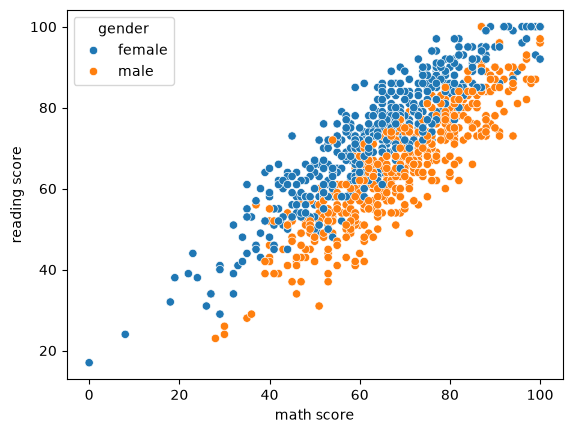

In [3]:
'''
sns.graph_type(
    data=df,
    x="column_name",
    y="another_column",
    hue="grouping_column"
)
'''
# For Example: 

sns.scatterplot(
    data=df,
    x="math score",
    y="reading score",
    hue="gender"
)

# x-axis = math score 
# y-axis = reading score 
# hue = Separate the observations using 
# different colors based on gender.


### 🟢 Creating one graph:

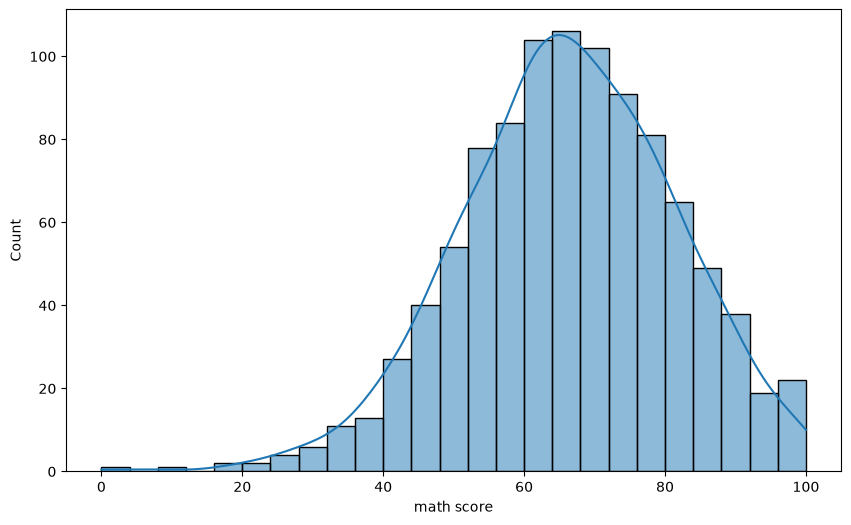

In [4]:
# Creating a new figure:
plt.figure(figsize=(10, 6)) 

# making a histogram
sns.histplot(data=df, x="math score", kde=True)

# Showing it:
plt.show()

### 🟢 Creating more than one graph for comparison:

Rsubplots are used to compare two distributions. Like math score vs reading score. 

Results : axes[0] (first graph)         |             axes[1] (second graph)

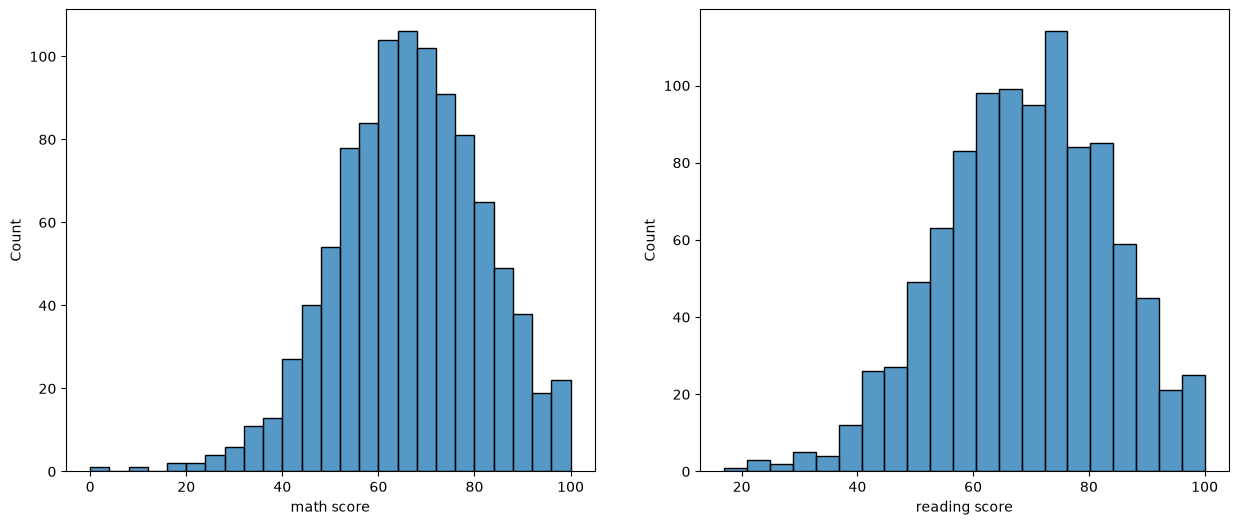

In [5]:
# Creating a figure: has 1 row, 2 cols, 2 graph area:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15,6)
)

# Passing each axis bto seaborn:
sns.histplot(
    data=df,
    x="math score",
    ax=axes[0]
)

sns.histplot(
    data=df,
    x="reading score",
    ax=axes[1]
)

plt.show()

# 🔵 Data Visualization
We have to figure which type we want to use: **Univariate, Bivariate or Multivariate**. 

- Univariate: studying one variable
- Bivariate: studying the relationship between two variables
- Multivariate: studying three or more variables together

Steps:
### 🟢 1. Start by identifying the variable types
1. Numerical variables (math, reading, writing score, age, ...) Discrete and continuous
2. Categorical variables (gender, race, country, ...) Nominal, Ordinal
    * Nominal: Categories have no natural order: country, race, gender, ...
    * Ordinal: Categories have a meaningful order: (Low, medium, high), (Beginner, intermediate, advanced), (Poor, fair, good, excellent)

### 🟢 2. The graph-selection framework
1. Questions to ask: 
    * first: How many variables am I examining?
    * second: What type is each variable


| Variables                 | Main question                        | Good graphs                                   |
| ------------------------- | ------------------------------------ | --------------------------------------------- |
| One numerical             | What is its distribution?            | Histogram, KDE, boxplot                       |
| One categorical           | How common is each category?         | Countplot, bar chart                          |
| Numerical + numerical     | Are the variables related?           | Scatterplot, regplot                          |
| Categorical + numerical   | How does a number differ by group?   | Boxplot, violin plot, barplot                 |
| Categorical + categorical | Are the categories associated?       | Grouped countplot, stacked bar chart, heatmap |
| Time + numerical          | How does a value change over time?   | Line plot                                     |
| Several numerical         | How are numeric features related?    | Pairplot, correlation heatmap                 |
| Three variables           | Does a relationship differ by group? | `hue`, faceting, grouped plots                |

Another way to choose:

When you are unsure, ask these questions in order:
1. How many variables am I examining?
2. Is each variable numerical or categorical?
3. Am I studying distribution, count, relationship, comparison, or time?
4. Do I need raw observations or only a summary?
5. Do I need to compare another group?


| Goal                                    | Graph               |
| --------------------------------------- | ------------------- |
| Distribution of one number              | Histogram           |
| Smooth distribution shape               | KDE                 |
| Compact spread and outliers             | Boxplot             |
| Number of observations per category     | Countplot           |
| Mean number across categories           | Barplot             |
| Full numeric distribution across groups | Violin plot         |
| Actual points across groups             | Stripplot/swarmplot |
| Relationship between two numbers        | Scatterplot         |
| Linear trend between two numbers        | Regplot             |
| Change over time                        | Line plot           |
| Pairwise numeric relationships          | Pairplot            |
| Numerical correlation overview          | Heatmap             |
| Few-category part of a whole            | Pie chart           |
| Relationship split by another category  | `hue` or facets     |

#### 🔵 **3. Histogram — numerical distributions**
#### 🔵 **4. KDE**
#### 🔵 **5. Countplot — categorical frequencies and class balance**
#### 🔵 **6. Barplot — comparison of group means or other aggregates**
#### 🔵 **7. Boxplot — numerical distributions across categories and potential outliers**
#### 🔵 **8. Violinplot**
#### 🔵 **9. Stripplot and swarmplot**
#### 🔵 **10. Scatterplot — relationships between numerical variables**
#### 🔵 11. Regression plot
#### 🔵 **12. Line plot — time series and training history**
#### 🔵 13. Pie chart
#### 🔵 **14. Pairplot — rapid inspection of selected numerical relationships**
#### 🔵 **15. Correlation heatmap — overview of numerical relationships**
#### 🔵 16. Heatmap for missing values
#### 🔵 17. Grouped bar charts
#### 🔵 18. **Stacked bar chart**
#### 🔵 19. **Faceting**
#### 🔵 20. Choosing between similar graphs

________________________________________________________________________

# 🟣 1. Histogram & KDE: 
A histogram is for a numerical variable divided into intervals.
* Answers: **How is one numerical variable distributed?**

* KDE means Kernel Density Estimate. It gives an approximate smooth shape of a numerical distribution. 
* When to use? Analyzing one numerical feature. 
* Examples: Distribution of house prices, student score, salaries, ...

#### 🟢 Code for histogram: 

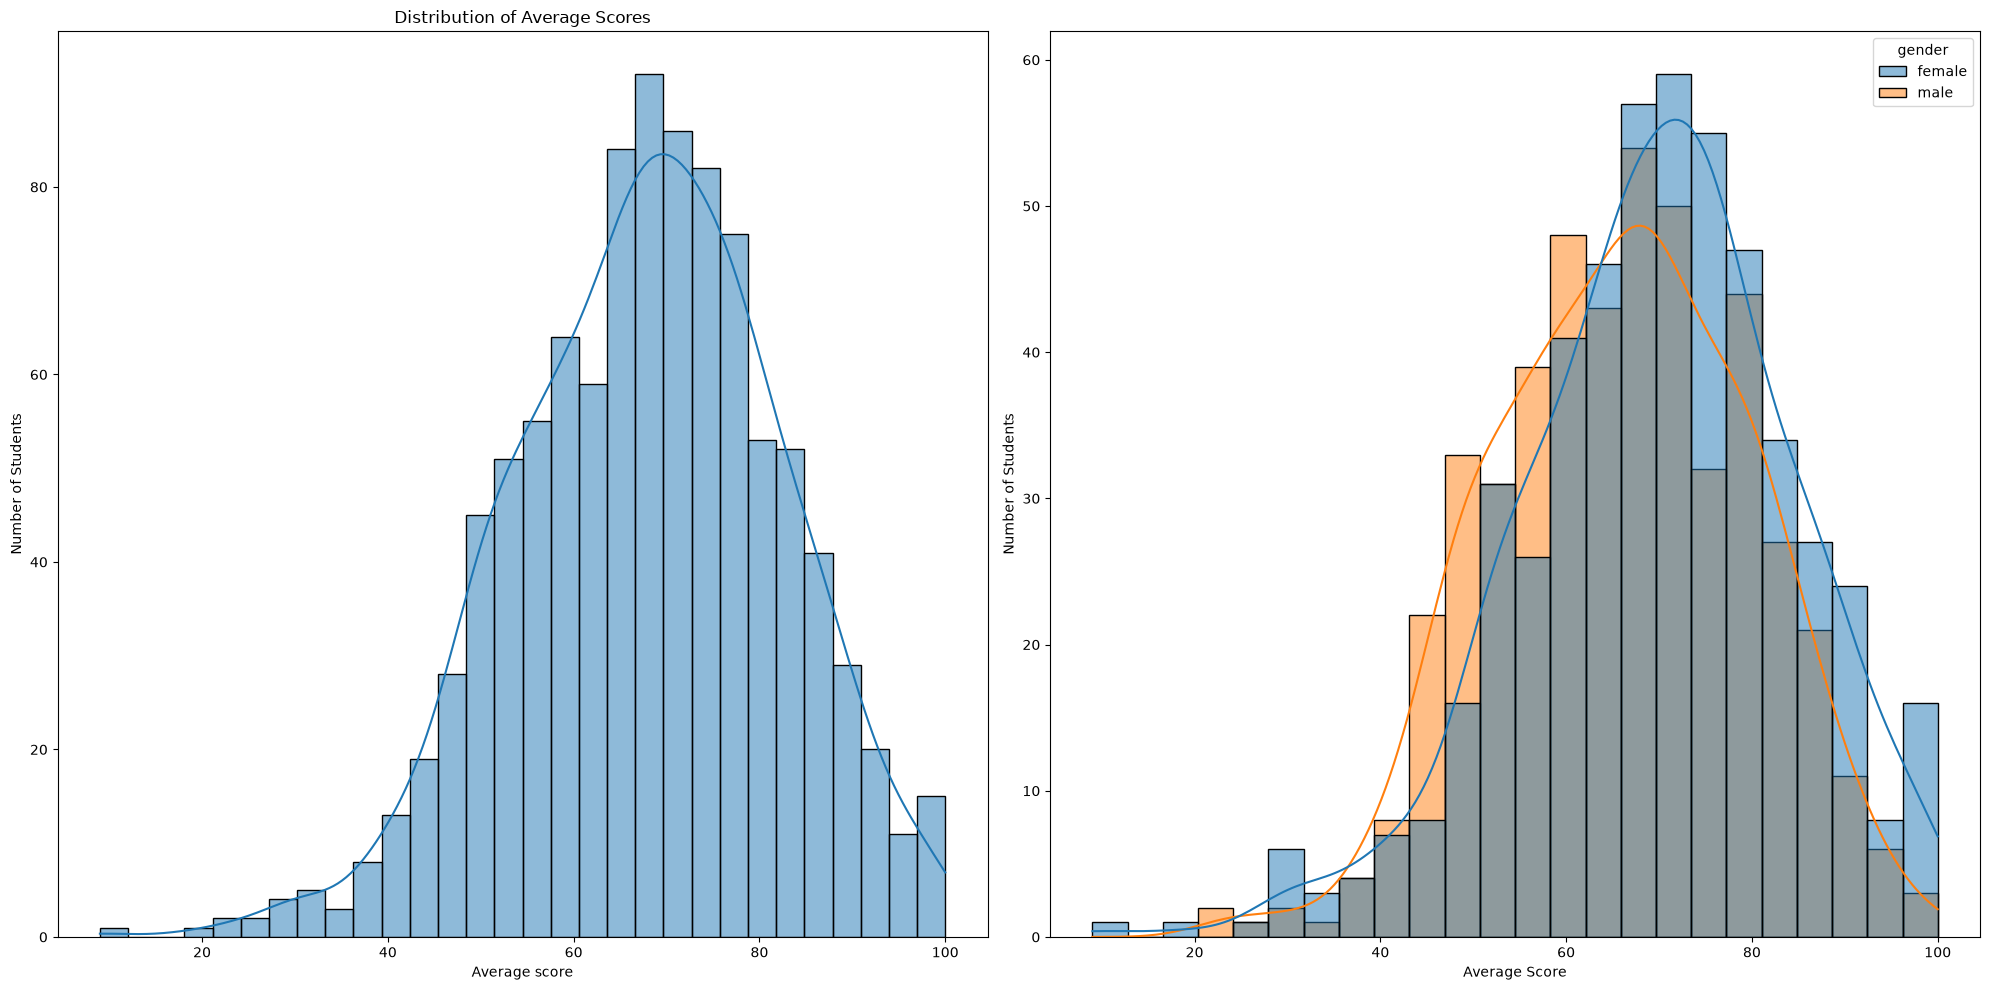

In [6]:
# Creating two subplots:
fig, axes = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(20,10)
)

df["average"] = (df["math score"] + df["reading score"] + df["writing score"]) / 3
# use sns to make the histogram for axes[0]:
sns.histplot(
    data = df, 
    x = "average", 
    bins = 30, 
    kde = True, 
    ax = axes[0]
)

# Setting notes for axes[0]
axes[0].set_title("Distribution of Average Scores")
axes[0].set_xlabel("Average score")
axes[0].set_ylabel("Number of Students")

# Creating histogram for axes[1] 
sns.histplot(
    data = df, 
    x = "average", 
    hue = "gender", 
    kde = True, 
    ax = axes[1]
)

# Setting notes for axes[1]
axes[1].set_label("Distribution of Average Based on Gender")
axes[1].set_xlabel("Average Score")
axes[1].set_ylabel("Number of Students")


plt.tight_layout() # Fitting the graphs to figure size
plt.show()

#### 🟢 Code for KDE: 

<Axes: xlabel='math score', ylabel='Density'>

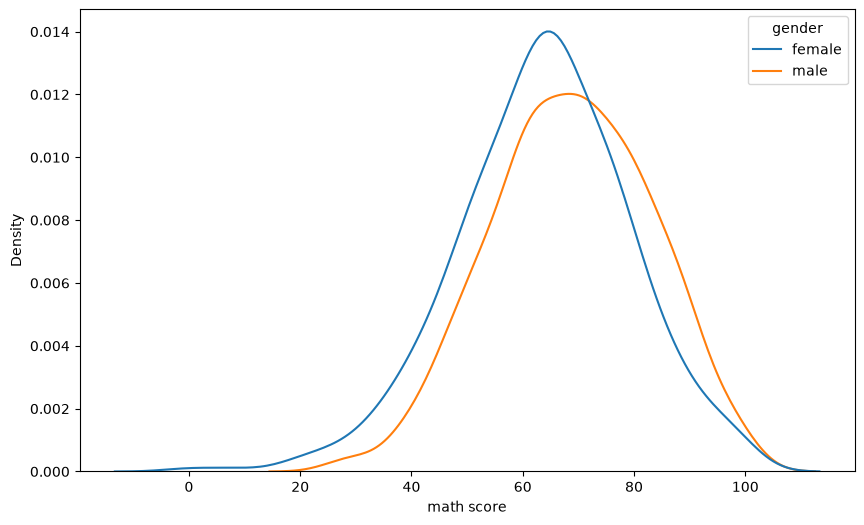

In [7]:
# Making a figure for KDE plot:
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data = df, 
    x = "math score", 
    hue = "gender"    
)

# KDE answers where the data is most densely concentrated. 

# 🟣 Countplot:
Countplot counts how many observations belong to each category.
* Answers: **How many observations belong to each category?**

* When to use? Counting for one categorical variable. 
* Examples: # of Male vs female, lunch types, race, ...

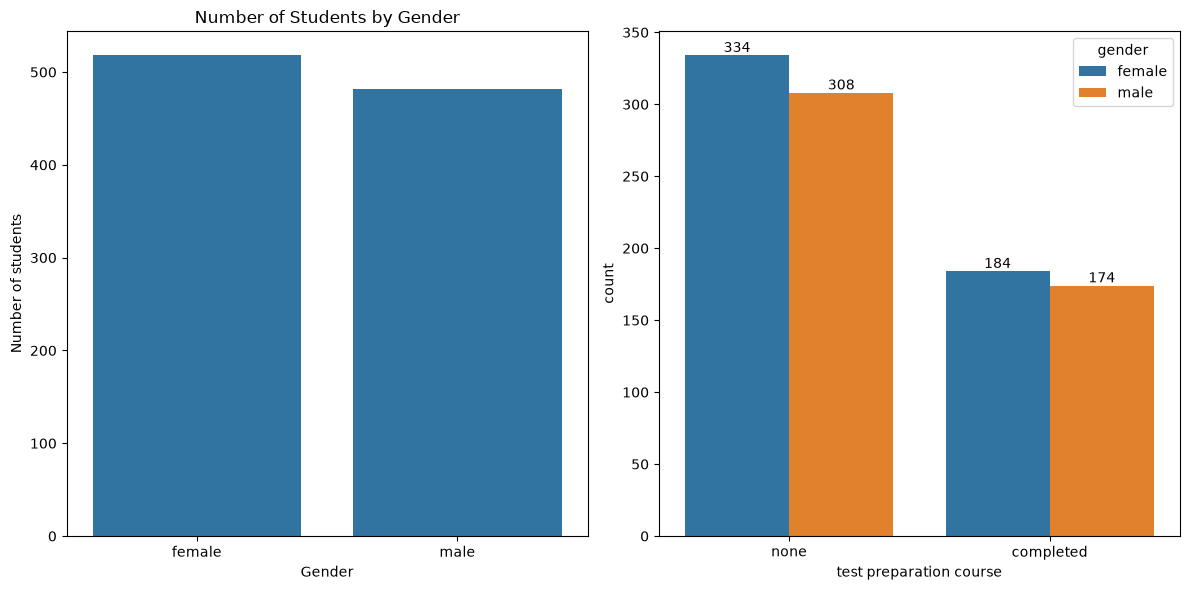

In [8]:
fig, axes = plt.subplots(
    nrows = 1, 
    ncols = 2,
    figsize=(12, 6))


# Plotting the bar graph 
first_bar_graph = sns.countplot(
    data=df,
    x="gender", 
    ax = axes[0]
)

first_bar_graph.set_title("Number of Students by Gender")
first_bar_graph.set_xlabel("Gender")
first_bar_graph.set_ylabel("Number of students")


# Plotting the second bar graph:
second_bar_graph = sns.countplot(
    data = df, 
    x = "test preparation course", 
    hue = "gender", 
    ax = axes[1]
)

# writes numeric value on each bar
# A bar chart stores its bars in containers.

for container in second_bar_graph.containers:
    second_bar_graph.bar_label(container) 

plt.tight_layout()
plt.show()


# 🟣 Barplot:
Compares an aggregated numerical value (usually the mean) across categories.
* Answers: **Which category has the highest average?**

* When to use? Categorical + Numerical
* Examples: Average salary by department, Average score by gender, Average house price by city
* Results: Average + Comparison between groups. 

<function matplotlib.pyplot.show(close=None, block=None)>

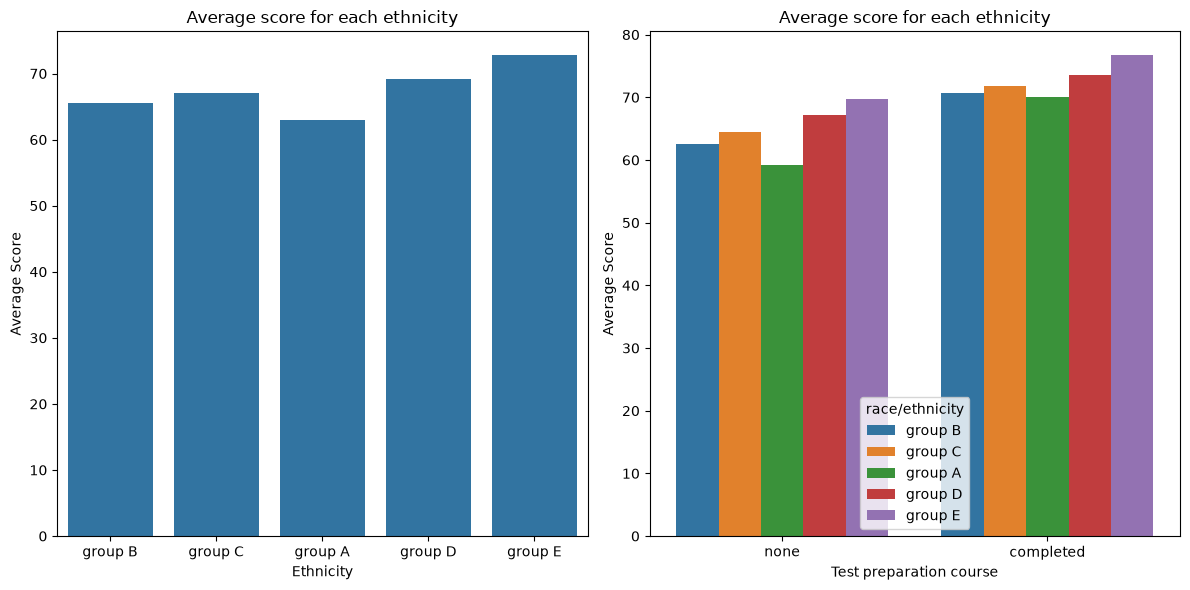

In [15]:
df["average"] = (df["math score"] + df["reading score"] + df["writing score"]) / 3

# Goal seeing how the race and test preperation course affected average
fig, axes = plt.subplots(
    nrows = 1, 
    ncols = 2, 
    figsize = (12, 6)
)

first_barplot = sns.barplot(
    data = df, 
    x = "race/ethnicity", 
    y = "average", 
    errorbar=None, 
    ax = axes[0]
)

first_barplot.set_title("Average score for each ethnicity")
first_barplot.set_xlabel("Ethnicity")
first_barplot.set_ylabel("Average Score")

second_barplot = sns.barplot(
    data = df, 
    x = "test preparation course", 
    y = "average", 
    hue = "race/ethnicity",
    errorbar=None,
    ax = axes[1]
)

second_barplot.set_title("Average score for each ethnicity")
second_barplot.set_xlabel("Test preparation course")
second_barplot.set_ylabel("Average Score")

plt.tight_layout()
plt.show



# 🟣 Boxplot:
Shows the distribution of numerical values across categories.
* Answers: **How are these groups different?**

* When to use? Categorical + Number
* Examples: Salary by department, score by gender, house price by neighborhood
* Results: Median, Spread, comparing gropus. 
* How to compare?
    * Compare the medians
    * Compare the spread (A longer box means higher variability so it has a greater spread of values.)

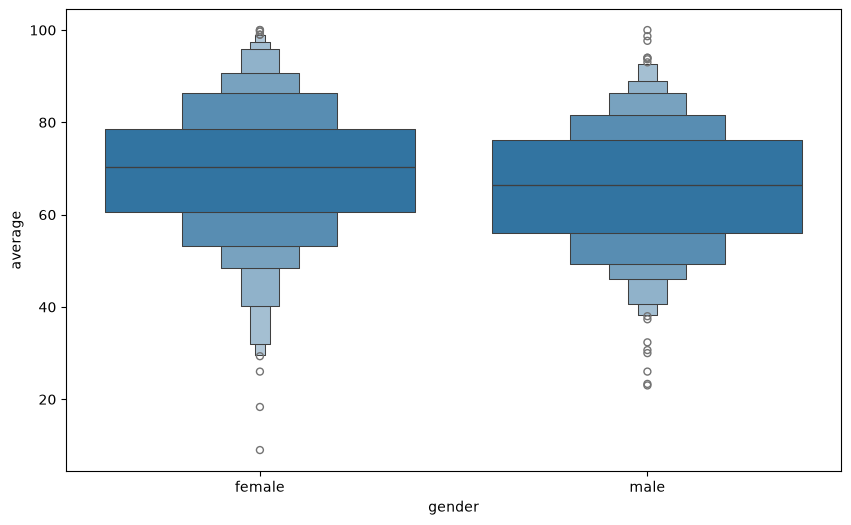

In [21]:
plt.figure(figsize=(10,6))
sns.boxenplot( # or boxplot (boxenplot has more info)
    data=df,
    x="gender",
    y="average"
)

plt.show()

# 🟣 Violinplot:
Shows the shape of distribution. 
* Answers: **What does the distribution look like inside each category?**

* When to use? Categorical/num + Number
* Examples: Salary by department, score by gender, house price by neighborhood
* Results: Distribution density + median + spread
* How to compare?
    * Compare the medians
    * Compare the spread + distribution

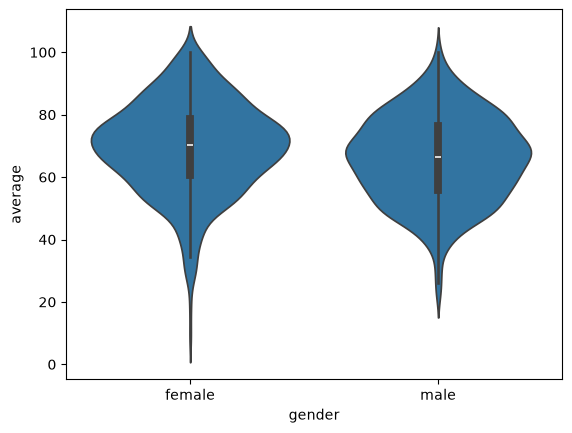

In [22]:
sns.violinplot(
    data=df,
    x="gender",
    y="average"
)

plt.show()